# 📘 Lecture 10: Multivariate Probability Models, Covariance, Simpson's Paradox, & Multivariate Gaussians
**Course**: Probabilistic Machine Learning by Aayush  
**Video Reference**: [Lecture 10 - YouTube](https://youtu.be/nEhaQlKRAGY?si=yEOWP6rM5z6rnDN-)

---
### 📌 Executive Overview & Core Objectives
In this lecture, we transition from univariate random variables to multivariate random vectors $\mathbf{X} \in \mathbb{R}^D$ and study their joint distributions:
1. **Covariance Matrix $\boldsymbol{\Sigma}$**: Measuring linear dependence across $D$ dimensions, proving symmetry and positive semi-definiteness (PSD), and normalizing into the Pearson Correlation Matrix $\mathbf{R}$.
2. **Uncorrelatedness vs. Independence**: Demonstrating why zero covariance $\text{Cov}(X, Y) = 0$ does **not** imply independence (e.g. $Y = X^2$ for $X \sim \text{Unif}(-1, 1)$), introducing Mutual Information, and dissecting confounding causation.
3. **Simpson's Paradox**: Explaining how subgroup trends reverse upon aggregation via the Law of Total Probability (COVID-19 Italy vs. China age-stratified case study).
4. **Multivariate Gaussian Distribution**: $D$-dimensional PDF formulation, exponent quadratic form, and 3D surface visualizations.
5. **Level Sets, Mahalanobis Distance & Eigen-Decomposition**: Analyzing level sets $(\mathbf{y} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{y} - \boldsymbol{\mu}) = r^2$, proving how eigenvectors $\mathbf{u}_d$ determine ellipse orientation and eigenvalues $\lambda_d$ determine elongation for Spherical, Diagonal, and Full covariance structures.

---


## 0️⃣ Environment Setup & Imports
We start by importing scientific computation, linear algebra, and 3D visualization packages.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import seaborn as sns

# Set random seed for 100% reproducible results
np.random.seed(42)
print("✅ Libraries imported successfully! NumPy Version:", np.__version__)


✅ Libraries imported successfully! NumPy Version: 2.1.3


## 1️⃣ Joint Distributions, Covariance Matrix & Correlation

### 1.1 Mathematical Formalism
For a $D$-dimensional random vector $\mathbf{X} = [X_1, X_2, \dots, X_D]^\top \in \mathbb{R}^D$ with mean vector $\boldsymbol{\mu} = \mathbb{E}[\mathbf{X}] \in \mathbb{R}^D$:
$$\boldsymbol{\Sigma} = \text{Cov}(\mathbf{X}) = \mathbb{E}[(\mathbf{X} - \boldsymbol{\mu})(\mathbf{X} - \boldsymbol{\mu})^\top] = \mathbb{E}[\mathbf{X}\mathbf{X}^\top] - \boldsymbol{\mu}\boldsymbol{\mu}^\top$$

#### Properties of Covariance Matrix $\boldsymbol{\Sigma} \in \mathbb{R}^{D \times D}$:
1. **Symmetry**: $\boldsymbol{\Sigma}_{ij} = \text{Cov}(X_i, X_j) = \text{Cov}(X_j, X_i) = \boldsymbol{\Sigma}_{ji} \implies \boldsymbol{\Sigma}^\top = \boldsymbol{\Sigma}$.
2. **Positive Semi-Definiteness (PSD)**: For any vector $\mathbf{v} \in \mathbb{R}^D$:
   $$\mathbf{v}^\top \boldsymbol{\Sigma} \mathbf{v} = \mathbf{v}^\top \mathbb{E}[(\mathbf{X} - \boldsymbol{\mu})(\mathbf{X} - \boldsymbol{\mu})^\top] \mathbf{v} = \mathbb{E}\left[ \left( \mathbf{v}^\top (\mathbf{X} - \boldsymbol{\mu}) \right)^2 \right] \ge 0$$
3. **Diagonal Entries**: $\boldsymbol{\Sigma}_{ii} = \text{Var}(X_i) = \sigma_i^2$.

### 1.2 Pearson Correlation Matrix $\mathbf{R}$
Normalizing covariance by standard deviations $\sigma_i = \sqrt{\boldsymbol{\Sigma}_{ii}}$:
$$\rho_{ij} = \frac{\text{Cov}(X_i, X_j)}{\sigma_i \sigma_j} \in [-1, 1], \quad \mathbf{R} = \mathbf{D}^{-1/2} \boldsymbol{\Sigma} \mathbf{D}^{-1/2}, \quad \mathbf{D} = \text{diag}(\boldsymbol{\Sigma})$$


In [5]:
#Start code here..
N_samples = 100000
#3D gaussian distribution
#True means and variances
true_mu = np.array([2.0, -1.0, 3.0])
true_sigma = np.array([
    [4.0, 1.2, -0.8],
    [1.2, 1.0, 0.3],
    [-0.8, 0.3, 2.2]
])
#Generate a large number of samples from the multivariate normal distribution using the defined mean and covariance
X_samples = np.random.multivariate_normal(true_mu, true_sigma, size=N_samples)

#Compute the empirical mean vector from the generated samples
emp_mu = np.mean(X_samples, axis=0)
emp_Sigma = np.cov(X_samples, rowvar=False)

D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(emp_Sigma)))
emp_R = D_inv_sqrt @ emp_Sigma @ D_inv_sqrt

#End code here..
print("📊 Empirical Covariance Matrix Σ:")
print(emp_Sigma.round(4))
print("\n🔗 Normalized Pearson Correlation Matrix R:")
print(emp_R.round(4))


📊 Empirical Covariance Matrix Σ:
[[ 4.0209  1.2148 -0.8053]
 [ 1.2148  1.008   0.2937]
 [-0.8053  0.2937  2.2034]]

🔗 Normalized Pearson Correlation Matrix R:
[[ 1.      0.6034 -0.2705]
 [ 0.6034  1.      0.1971]
 [-0.2705  0.1971  1.    ]]


## 2️⃣ Uncorrelatedness vs. Independence & Confounding Causation

### 2.1 Uncorrelatedness Does NOT Imply Independence
If $X \perp Y$, then $\text{Cov}(X, Y) = 0$. However, $\text{Cov}(X, Y) = 0$ only measures **linear** independence.

#### Deterministic Non-Linear Counterexample:
Let $X \sim \text{Unif}(-1, 1)$ and $Y = X^2$. $Y$ is completely deterministically dependent on $X$.
However:
$$\mathbb{E}[X] = 0, \quad \mathbb{E}[XY] = \mathbb{E}[X^3] = 0 \implies \text{Cov}(X, Y) = \mathbb{E}[XY] - \mathbb{E}[X]\mathbb{E}[Y] = 0$$
The Pearson correlation $\rho_{XY} = 0$ despite perfect deterministic dependence!

### 2.2 Correlation Does NOT Imply Causation (Confounding Factor)
Consider Ice Cream Sales ($X$) and Crime Rates ($Y$). Both spike in summer due to a hidden confounding variable: High Temperature ($Z$).

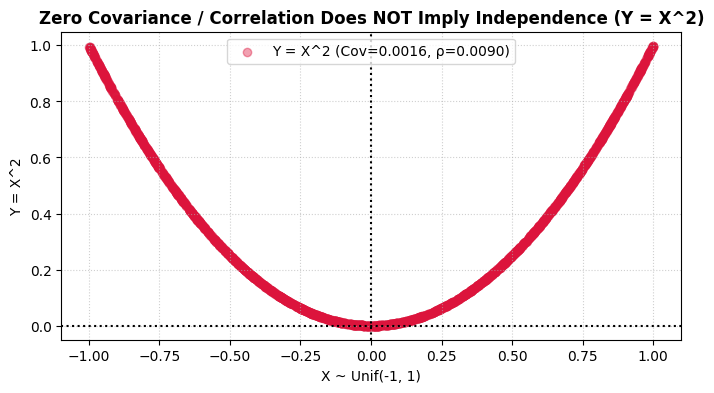

 Covariance Cov(X, Y=X^2): 0.001568  (Numerically 0!)
 Pearson Correlation ρ:    0.009001  (Linear Metric Fails!)


In [6]:
#Start code here..
N_pts  = 10000
#Generate a uniform distributed random numbers for X between -1 and 1
x_unif = np.random.uniform(-1,1,N_pts)
y_sq = x_unif ** 2

cov_xy = np.cov(x_unif, y_sq)[0,1]
corr_xy, _ = stats.pearsonr(x_unif, y_sq)

#End code here..
plt.figure(figsize=(8, 4))
plt.scatter(x_unif[::5], y_sq[::5], color='crimson', alpha=0.4, label=f'Y = X^2 (Cov={cov_xy:.4f}, ρ={corr_xy:.4f})')
plt.axhline(0, color='black', linestyle=':')
plt.axvline(0, color='black', linestyle=':')
plt.xlabel('X ~ Unif(-1, 1)')
plt.ylabel('Y = X^2')
plt.title('Zero Covariance / Correlation Does NOT Imply Independence (Y = X^2)', fontweight='bold')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

print(f" Covariance Cov(X, Y=X^2): {cov_xy:.6f}  (Numerically 0!)")
print(f" Pearson Correlation ρ:    {corr_xy:.6f}  (Linear Metric Fails!)")


## 3️⃣ Simpson's Paradox (COVID-19 Case Study)

### 3.1 Mathematical Formalism
Simpson's Paradox occurs when a statistical trend observed in distinct subgroups reverses when the subgroups are aggregated.

By the Law of Total Probability, overall mortality given country $C$ is:
$$P(\text{Fatality}=1 \mid C) = \sum_{a} \underbrace{P(\text{Fatality}=1 \mid \text{Age}=a, C)}_{\text{Age-Specific Mortality}} \cdot \underbrace{P(\text{Age}=a \mid C)}_{\text{Demographic Proportion}}$$

#### The COVID-19 Italy vs. China Paradox:
- For *every individual age group* $a$, China had higher case fatality rates than Italy:
  $$P(F=1 \mid A=a, C=\text{China}) > P(F=1 \mid A=a, C=\text{Italy}) \quad \forall a$$
- However, Italy had a significantly older demographic ($P(A=\text{Elderly} \mid C=\text{Italy}) \gg P(A=\text{Elderly} \mid C=\text{China})$).
- Because older age groups have drastically higher base mortality rates, the aggregated sum $P(F=1 \mid C=\text{Italy}) > P(F=1 \mid C=\text{China})$!

In [7]:
#Start code here...
age_groups = ['Young(<50)', 'Middle(50-70)', 'Elderly(>70)']
#age-specific mortality rates
mortality_china = np.array([0.005, 0.030, 0.120])
mortality_italy = np.array([0.003, 0.025, 0.100])
#demographic distribution of infected cases
demo_china = np.array([0.70, 0.20, 0.10])
demo_italy = np.array([0.25, 0.25, 0.40])
#calculate the aggregated total mortality for china and italy using the law of total probability
total_mortality_china = np.sum(mortality_china * demo_china)
total_mortality_italy = np.sum(mortality_italy * demo_italy)

df_simpson = pd.DataFrame({
    'Age Group': age_groups,
    'China Age Mortality' : mortality_china,
    'Italy Age Mortality': mortality_italy,
    'China Demographic' : demo_china,
    'Italy demographic' : demo_italy
})


#End code here..
print("📊 Simpson's Paradox Breakdown:")
print(df_simpson.to_string(index=False))
print(f"\n🏴 Aggregated Overall Mortality - China: {total_mortality_china*100:.2f}%")
print(f"🇮🇹 Aggregated Overall Mortality - Italy: {total_mortality_italy*100:.2f}%  (REVERSED!)")


📊 Simpson's Paradox Breakdown:
    Age Group  China Age Mortality  Italy Age Mortality  China Demographic  Italy demographic
   Young(<50)                0.005                0.003                0.7               0.25
Middle(50-70)                0.030                0.025                0.2               0.25
 Elderly(>70)                0.120                0.100                0.1               0.40

🏴 Aggregated Overall Mortality - China: 2.15%
🇮🇹 Aggregated Overall Mortality - Italy: 4.70%  (REVERSED!)


## 4️⃣ Multivariate Gaussian Distribution

### 4.1 $D$-Dimensional Probability Density Function
For $\mathbf{Y} \in \mathbb{R}^D$ with mean vector $\boldsymbol{\mu} \in \mathbb{R}^D$ and covariance matrix $\boldsymbol{\Sigma} \in \mathbb{R}^{D \times D}$:
$$p(\mathbf{y} \mid \boldsymbol{\mu}, \boldsymbol{\Sigma}) = \frac{1}{(2\pi)^{D/2} |\boldsymbol{\Sigma}|^{1/2}} \exp\left( -\frac{1}{2} (\mathbf{y} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{y} - \boldsymbol{\mu}) \right)$$


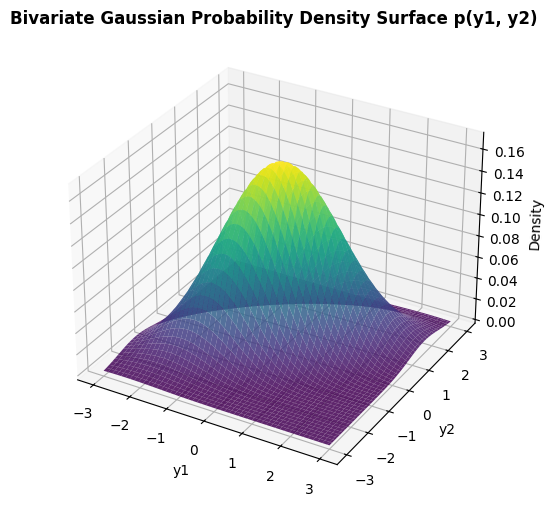

In [8]:
#Start code here..
mu_2d = np.array([0.0, 0.0])
sigma_2d = np.array([[1.5,0.8],
                     [0.8, 1.0]])

y1_grid = np.linspace(-3,3,100)
y2_grid = np.linspace(-3,3,100)
Y1, Y2 = np.meshgrid(y1_grid, y2_grid)
#we stack Y1 and Y2 to form position vectors for each point in the grid
pos = np.dstack((Y1, Y2))

#Create the multivariate
rv = stats.multivariate_normal(mu_2d, sigma_2d)
Z_pdf = rv.pdf(pos)

#End code here..
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Y1, Y2, Z_pdf, cmap='viridis', edgecolor='none', alpha=0.85)
ax.set_title('Bivariate Gaussian Probability Density Surface p(y1, y2)', fontweight='bold')
ax.set_xlabel('y1')
ax.set_ylabel('y2')
ax.set_zlabel('Density')
plt.show()


## 5️⃣ Level Sets, Mahalanobis Distance & Spectral Eigen-Decomposition

### 5.1 Mahalanobis Distance & Level Sets
The Mahalanobis Distance $\Delta$ measures statistical distance normalized by covariance:
$$\Delta^2 = (\mathbf{y} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{y} - \boldsymbol{\mu})$$

Level sets of constant probability density $p(\mathbf{y}) = c$ correspond to surfaces of constant Mahalanobis distance $\Delta^2 = r^2$.

### 5.2 Spectral Eigen-Decomposition Proof of Elliptical Contours
Since $\boldsymbol{\Sigma}$ is symmetric and positive definite, its inverse decomposes as:
$$\boldsymbol{\Sigma}^{-1} = \mathbf{U} \boldsymbol{\Lambda}^{-1} \mathbf{U}^\top = \sum_{d=1}^D \frac{1}{\lambda_d} \mathbf{u}_d \mathbf{u}_d^\top$$

Transforming to rotated coordinates $z_d = \mathbf{u}_d^\top (\mathbf{y} - \boldsymbol{\mu})$:
$$(\mathbf{y} - \boldsymbol{\mu})^\top \boldsymbol{\Sigma}^{-1} (\mathbf{y} - \boldsymbol{\mu}) = \sum_{d=1}^D \frac{z_d^2}{\lambda_d} = r^2$$

This is the standard equation of a $D$-dimensional **Ellipse**:
- **Eigenvectors $\mathbf{u}_d$**: Determine the **orientation** (principal axes).
- **Eigenvalues $\lambda_d$**: Determine the **elongation / variance** along each principal axis.

### 5.3 Covariance Types
1. **Spherical**: $\boldsymbol{\Sigma} = \sigma^2 \mathbf{I}$ (Circular contours, 1 parameter).
2. **Diagonal**: $\boldsymbol{\Sigma} = \text{diag}(\sigma_1^2, \dots, \sigma_D^2)$ (Axis-aligned ellipses, $D$ parameters).
3. **Full Covariance**: Arbitrarily rotated ellipses ($D(D+1)/2$ parameters).


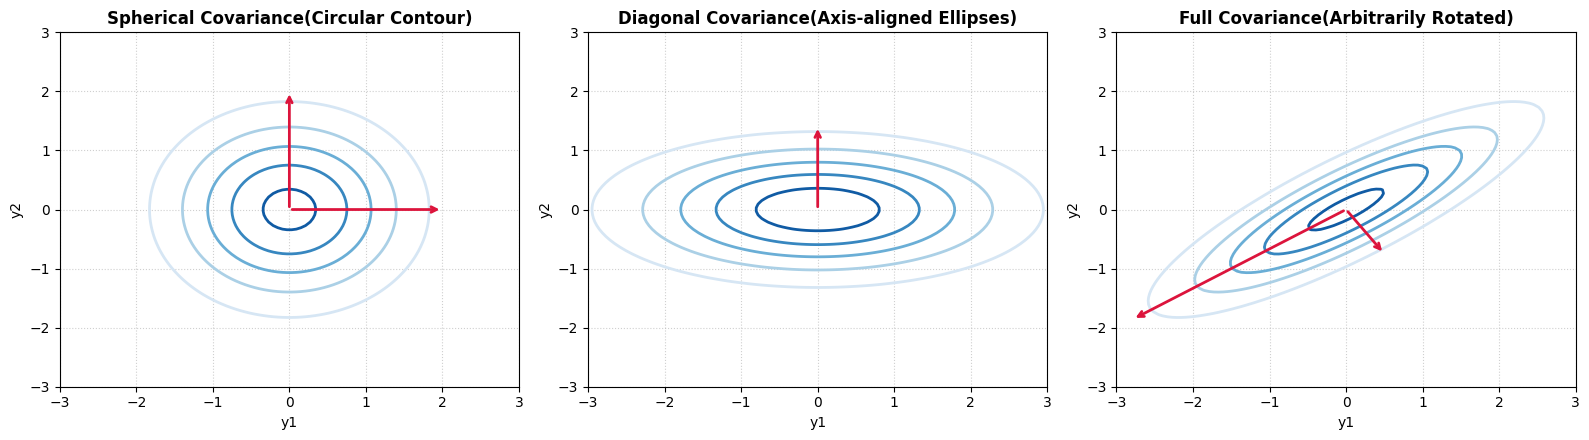

In [9]:
#Start code here..
fig, axes = plt.subplots(1,3, figsize=(16,4.5))
cov_spherical = np.array([[1.0, 0.0], [0.0, 1.0]])
cov_diagonal = np.array([[2.5, 0.0], [0.0, 0.5]])
cov_full = np.array([[2.0, 1.2], [1.2, 1.0]])

covs = [cov_spherical, cov_diagonal, cov_full]
titles = ['Spherical Covariance(Circular Contour)', 'Diagonal Covariance(Axis-aligned Ellipses)', 'Full Covariance(Arbitrarily Rotated)']

for idx, (cov_mat, title) in enumerate(zip(covs, titles)):
    rv_i = stats.multivariate_normal([0,0], cov_mat)
    z_i = rv_i.pdf(pos)
    axes[idx].contour(Y1, Y2, z_i, levels=5, cmap='Blues', linewidths=2)
    evals, evecs = np.linalg.eigh(cov_mat)

    #End code here..
    for v_idx in range(2):
        #Start code here...
        vec = evecs[: , v_idx] * np.sqrt(evals[v_idx]) * 2.0
        #End code here..
        axes[idx].annotate('', xy=vec, xytext=(0,0),
                           arrowprops=dict(facecolor='crimson', edgecolor='crimson', arrowstyle='->', lw=2))

    axes[idx].set_title(title, fontweight='bold')
    axes[idx].set_xlabel('y1')
    axes[idx].set_ylabel('y2')
    axes[idx].set_xlim(-3, 3)
    axes[idx].set_ylim(-3, 3)
    axes[idx].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
